# Notebook for practical exercises | Week #2 Lesson #3

## Introduction

This notebook contains practical hands-on exercises for the lesson about *Data annotation*.

After this session, you will know how to:
* Extract information and labels from radiology reports ;
* Load and convert DICOM files into other file formats ;
* Realize manual and AI-based annotations using 3D slicer ;
* Save these information in a machine-readable format.

To do the exercise and learn to annotate your data, you need to download the software **3D Slicer** - [[Download]](https://download.slicer.org/) [[Documentation]](https://slicer.readthedocs.io/en/latest/)


## Part 1 - Extracting metadata from radiology reports

Knowledge extraction from radiology reports involves the automated identification and structuring of critical clinical information—such as patient demographics, diagnoses, anatomical locations, and measurements—from unstructured text.

Given the growing volume of imaging studies, manual data extraction is time-consuming and prone to error, making automated knowledge extraction a valuable tool for advancing precision medicine and enhancing patient care.

In this first part, we will implement a baseline method to extract relevant knowledge from patient reports.

<div class="alert alert-block alert-danger">
<b>WARNING</b> - We will use a publicly available dataset of medical imaging reports for this course. The ReMIND dataset does not contain radiology reports, but the intuition behind this exercise would be the same for such dataset.
</div>

### Download the reports

Run the following cells to download the reports dataset.

<div class="alert alert-block alert-danger">
<b>Replace the <code>DATA_PATH</code> with the path where you want to store the data folder. By default, it will be stored at the root of this repository.</b> <br>
</div>

In [5]:
# retrieve the content from the repository
!git clone https://github.com/albarqounilab/AIM.git

In [16]:
import pandas as pd
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import seaborn as sns

import re
import sys
sys.path.append('AIM/notebooks/week2')

In [17]:
DATA_PATH = sys.path[-1]
!mkdir {DATA_PATH}/data
!curl https://uni-bonn.sciebo.de/s/hJSV1a3fJO5QfBh/download --output {DATA_PATH}/data/ReportsDATASET.csv

mkdir: cannot create directory ‘AIM/notebooks/week2/data’: File exists
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 61805  100 61805    0     0   102k      0 --:--:-- --:--:-- --:--:--  102k


In [19]:
# prompt: mkdir data if not with code

import os

if not os.path.exists(f'{DATA_PATH}/data'):
    os.makedirs(f'{DATA_PATH}/data')

!curl https://uni-bonn.sciebo.de/s/hJSV1a3fJO5QfBh/download --output {DATA_PATH}/data/ReportsDATASET.csv

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 61805  100 61805    0     0   119k      0 --:--:-- --:--:-- --:--:--  119k


In [20]:
reports = pd.read_csv(f'{DATA_PATH}/data/ReportsDATASET.csv') # Load the reports

The **radiologist reports** dataset includes radiology reports from chest X-rays and is used to explore the variability of reporting methods in radiology.

All sensitive patient information has been diligently replaced with X's to ensure privacy and confidentiality.

<div class="alert alert-block alert-info">
<b>Q1.</b> Explore a few radiology reports from the dataset using the code below. Compare the structure and think about potential metadata that could be extracted from these reports.
</div>

In [21]:
print(reports.iloc[9][0]) # COMPLETE WITH RANDOM INDEX NUMBERS


RADIOLOGY REPORT

EXAM
PA and lateral chest x-XXXX XXXX. HISTORY: XXXX-year-old male, chest pain. COMPARISON: Chest radiographs XXXX. FINDINGS: The cardiomediastinal silhouette is within normal limits for size and contour. The lungs are normally inflated without evidence of focal airspace disease, pleural effusion, or pneumothorax. Stable calcified granuloma within the right upper lung. No acute bone abnormality.. Transcribed by - PSC Transcription Date - XXXX

IMPRESSION
No acute cardiopulmonary process.

SIGNATURE
XXXX




<ipython-input-21-1508918753>:1: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  print(reports.iloc[9][0]) # COMPLETE WITH RANDOM INDEX NUMBERS


<div class="alert alert-block alert-info">
<b>Q2.</b> Use regex to extract one of the relevant information defined above. Analyze the results and conclude.
</div>

Use the following structure to write a function to search for regular expressions:
```python
def extract_indication(text):
    match = re.search(r"Indication.* ([\w\s\-]+)[\.\n]", text, re.IGNORECASE)
    return match.group(1).strip() if match else None
```

In [22]:
def extract_indication(text):
    match = re.search(r"Indication.* ([\w\s\-]+)[\.\n]", text, re.IGNORECASE)
    return match.group(1).strip() if match else None

extracted_data = []

for report in reports['Text']:
    loc = extract_indication(report)

    extracted_data.append(loc)

df_extracted = pd.DataFrame(extracted_data)
df_extracted

,0
0,test
1,None
2,None
3,None
4,congestion
...,...
109,None
110,XXXX\n\nIMPRESSION\nHyperexpanded but clear lungs
111,XXXX\n\nIMPRESSION\n1
112,None


In [23]:
print(f'Number of missed information:', len(df_extracted.loc[df_extracted[0].isna()]))

Number of missed information: 64


<div class="alert alert-block alert-info">
<b>Q3.</b> Use an LLM tool of your choice to extract informations from the reports and organize them as csv files. Compare with the results you obtained with the regular expression.
</div>

To write your prompt, use the following structure:

```
Please extract [LABEL], [LABEL], [LABEL], [LABEL], [LABEL], and [LABEL] from each of the following reports, format as [FORMAT].
```

Replace the `[LABEL]` with names of the metadata you would like to obtain, and change the `[FORMAT]` according to your preference: `json`, `csv`, `xlsx`, etc.

## Part 2 - Annotating images with 3D Slicer

**Segmentation** corresponds to the partitioning a medical image into multiple connected segments, where each region is homogeneous and identified by a unique label.

In our brain MRI dataset, we already have access to tumor segmentations. We will try to reproduce one of these segmentation and compare.

The goal of this exercise is to:
* Teach you how to use 3D slicer to visualize DICOM data ;
* Learn how to create and refine annotations ;
* Save these annotations in the appropriate format.

Start by **downloading and installing** 3D Slicer: [[Download]](https://download.slicer.org/) [[Documentation]](https://slicer.readthedocs.io/en/latest/)

Then, look at the following video and reproduce the following steps:

In [1]:
#@title run cell to load the video
import base64
from IPython.display import HTML

video_path = f"{DATA_PATH}/img/demo-3dslicer-segment.mp4"
b64 = base64.b64encode(open(video_path, "rb").read()).decode()

HTML(f"""
<video
  id="myvid"
  width="1280" height="720"
  controls
  style="cursor: pointer;"
  ondblclick="this.requestFullscreen()"
>
  <source src="data:video/mp4;base64,{b64}" type="video/mp4">
  Your browser doesn’t support HTML5 video.
</video>
""")

<div class="alert alert-block alert-info">
<b>Step 1.</b> Launch 3D Slicer and upload the DICOM folder of the ReMIND dataset. Load the T1w MRI from patient with <b>ID 001</b>.
</div>

<img src="https://github.com/albarqounilab/AIM/blob/main/notebooks/week2/img/slicer-1.png?raw=true" alt="1" width="800"/>
<img src="https://github.com/albarqounilab/AIM/blob/main/notebooks/week2/img/slicer-2.png?raw=true" alt="1" width="800"/>
<img src="https://github.com/albarqounilab/AIM/blob/main/notebooks/week2/img/slicer-3.png?raw=true" alt="1" width="800"/>
<img src="https://github.com/albarqounilab/AIM/blob/main/notebooks/week2/img/slicer-4.png?raw=true" alt="1" width="800"/>

<div class="alert alert-block alert-info">
<b>Step 2.</b> Place a marker at the center of the tumor.
</div>

<img src="https://github.com/albarqounilab/AIM/blob/main/notebooks/week2/img/slicer-5.png?raw=true" alt="1" width="800"/>

<div class="alert alert-block alert-info">
<b>Step 3.</b> Create a new segmentation of the tumor, use the color of your choice. Segment the tumor on 3 slices of each view using your favorite method.  
</div>

<img src="https://github.com/albarqounilab/AIM/blob/main/notebooks/week2/img/seg-1.png?raw=true" alt="1" width="400"/>

* **Paint**: use the brush to select pixels to include in the segmentation ;
    * Pick the radius (in millimeters) of the brush to apply
    * Left click to apply single circle
    * Left click and drag to fill a region
    * A trace of circles is left which are applied when the mouse button is released
    * Sphere mode applies the radius to slices above and below the current slice.

      
* **Draw**: draw the boundaries of the tumor using a pencil ;
    * Left click to lay individual points of an outline
    * Left drag to lay down a continuous line of points
    * Left double-click to add a point and fill the contour.
    * Alternatively, right click to fill the current contour without adding any more points.


* **Level tracing**: use pixel intensities to determine regions of interest.
    * Moving the mouse defines an outline where the pixels all have the same background value as the current background pixel
    * Clicking the left mouse button applies that outline to the label map

You can then use the Eraser to correct your mistakes. Be careful of the brush width to delineate the tumor.

<img src="https://github.com/albarqounilab/AIM/blob/main/notebooks/week2/img/slicer-6.png?raw=true" alt="2" width="800"/>
<img src="https://github.com/albarqounilab/AIM/blob/main/notebooks/week2/img/slicer-7.png?raw=true" alt="2" width="800"/>

<div class="alert alert-block alert-info">
<b>Step 4.</b> Use one of the semi-automatic tool available to complete segmentation and refine the tumor boundaries.  
</div>

<img src="https://github.com/albarqounilab/AIM/blob/main/notebooks/week2/img/seg-2.png?raw=true" alt="2" width="400"/>

* **Grow from seeds**: Draw segment inside each anatomical structure. This method will start from these “seeds” and grow them to achieve complete segmentation ;
* **Interpolate between slices**: Create complete segmentation on selected slices using any editor effect. You can skip any number of slices between segmented slices. This method will fill the skipped slices by interpolating between segmented slices. ;
* **Automatic thresholding**: use Threshold to determine a threshold range and save results to selected segment or use it as Editable intensity range.



<div class="alert alert-block alert-info">
<b>Step 5.</b> Save the tumor annotation that you just created in <b>NRRD</b> format.
</div>

<img src="https://github.com/albarqounilab/AIM/blob/main/notebooks/week2/img/slicer-8.png?raw=true" alt="2" width="800"/>

Compare your segmentation with the one performed by clinicians!

Tutorials and courses about 3D slicer:
* Loading and saving: [Course](https://data.kitware.com/api/v1/item/5b0f8d998d777f15ebe1fc21/download?contentDisposition=inline), [Tutorial](https://data.kitware.com/api/v1/item/5b0fde168d777f15ebe1fc99/download?contentDisposition=inline)
* Segmentation: [Course](https://data.kitware.com/api/v1/item/5c87a08c8d777f072b9185bf/download?contentDisposition=inline), [Exercises](https://data.kitware.com/#collection/568a9db98d777f429eac8eab/folder/5c86c2108d777f072b905359)

## Part 3 - Saving and converting DICOM data

Medical imaging data can be stored in several format. In neuroimaging, we mostly encounter **DICOM** and **NIfTI**.

The DICOM standard — **Digital Imaging and Communications in Medicine** (DICOM) — is used to exchange images and information and has been around for over over 20 years. The use of the DICOM format started to take off in the mid-nineties. DICOM comes with several support layers, allowing image senders and receivers to exchange information about the analyzed images.

The **Neuroimaging Informatics Technology Initiative** (NIfTI) was established to work with medical and research device users and manufacturers to address some of the problems and shortfalls of other imaging standards. The NIfTI standard was specifically designed to address these challenges in the neuroimaging field, focusing on functional magnetic resonance imaging (fMRI).

Source: [https://encord.com/blog/dicom-and-nifti-comparison/](https://encord.com/blog/dicom-and-nifti-comparison/)

There are several differences between DICOM and NIfTI. To train machine- or deep learning models with brain MRI, we need to load the full volume and we often prefer to use NIfTI for saving and loading. We will dive into this file format, learn how to convert DICOM to NIfTI and save the images.

In [76]:
!pip install dicom2nifti pydicom SimpleITK -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.6/52.6 MB 13.4 MB/s eta 0:00:00


In [77]:
import pydicom
import nibabel as nib
import dicom2nifti
import os
import SimpleITK as sitk

Ensure your DICOM files are organized in a single directory. Each DICOM series should be in its own folder. For this example, we have our `ReMIND` folder with `ReMIND-001` corresponding to the folder of subject one, and then the `preop` folder. Within this folder, we have access to DICOM folders with each folder corresponding to a serie.

<div class="alert alert-block alert-info">
<b>Q1.</b> Change the paths in the following cell and generate a NIfTI image from one of the DICOM serie.
</div>

In [83]:
# Donwload if needed
# !curl https://uni-bonn.sciebo.de/s/s1t8QUZ02MF1Qoh/download --output {DATA_PATH}/data.zip
# !unzip {DATA_PATH}/data.zip

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 1730M  100 1730M    0     0  70.4M      0  0:00:24  0:00:24 --:--:--  106M


<div class="alert alert-block alert-info">
<b>Q2.</b> Compare the information available in the NIfTI header vs. in the DICOM header. Does the NIfTI file format contain MORE or LESS information than the DICOM format?
</div>

In [91]:
dicom_directory = f'./data/ReMIND/sub-002/anat/T1w/'
output_file      = './nifti_file.nii'

# 1) Find the series (there may be multiple — adjust index if needed)
reader = sitk.ImageSeriesReader()
series_IDs = reader.GetGDCMSeriesIDs(dicom_directory)
if not series_IDs:
    raise ValueError(f"No DICOM series found in {dicom_directory}")

series_file_names = reader.GetGDCMSeriesFileNames(dicom_directory, series_IDs[0])
reader.SetFileNames(series_file_names)

# 2) Read + write
image = reader.Execute()
sitk.WriteImage(image, output_file)

print(f"Written NIfTI to {os.path.abspath(output_file)}")

Written NIfTI to /content/nifti_file.nii


In [93]:
# Verify the conversion
nifti_image = nib.load(output_file)
print(nifti_image.shape)
print(nifti_image.header)

(216, 256, 192)
<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : np.bytes_(b'')
db_name         : np.bytes_(b'')
extents         : 0
session_error   : 0
regular         : np.bytes_(b'r')
dim_info        : 0
dim             : [  3 216 256 192   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : int16
bitpix          : 16
slice_start     : 0
pixdim          : [1.         0.97656256 0.9765625  1.0000004  0.         0.
 0.         0.        ]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 10
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : np.bytes_(b'')
aux_file        : np.bytes_(b'')
qform_code      : scanner
sform_code      : scanner
quatern_b       : 0.9629378
quatern_c       : 0.05449336
qu

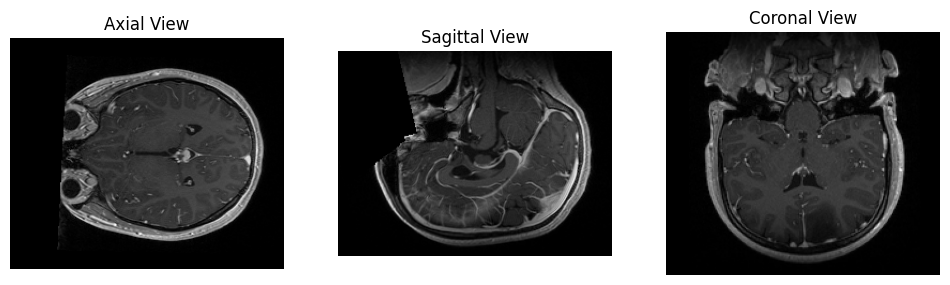

In [94]:
import matplotlib.pyplot as plt

# Get the image data as a numpy array
img_data = nifti_image.get_fdata()

# Get the dimensions of the image
width, height, depth = img_data.shape

# Display slices from different views
plt.figure(figsize=(12, 4))

# Axial view (slice through the z-axis)
plt.subplot(1, 3, 1)
plt.imshow(img_data[:, :, depth // 2], cmap='gray')
plt.title('Axial View')
plt.axis('off')

# Sagittal view (slice through the x-axis)
plt.subplot(1, 3, 2)
plt.imshow(img_data[width // 2, :, :].T, cmap='gray', origin='lower')
plt.title('Sagittal View')
plt.axis('off')

# Coronal view (slice through the y-axis)
plt.subplot(1, 3, 3)
plt.imshow(img_data[:, height // 2, :].T, cmap='gray', origin='lower')
plt.title('Coronal View')
plt.axis('off')

plt.show()